
# Lab: Self-Supervised Learning with SimCLR
In this lab, we will build a Contrastive Learning system from scratch.
We will use the SimCLR framework (Simple Framework for Contrastive Learning of Visual Representations).

**Goal:** Learn useful image features from CIFAR-10 *without* using any labels.

In [ ]:
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import copy

# Ignore all warnings
warnings.filterwarnings("ignore")

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Part 1: The Data Augmentation Pipeline
Contrastive learning relies on "views". We take one image and create two different versions of it.
The model must learn that these two versions are the "same" (Positive Pair).

Define the SimCLR transformations, which are as follows:
* Random resized crop with scale (0.5, 1.0) and size as a parameter,
* Random horizontal flip,
* Random color distortion (ColorJitter) with brightness, contrast, saturation, and hue parameters assigned to 0.8, 0.8, 0.8, and 0.2 respectively,
* Random grayscale with probability 0.2
* Conversion to pytorch tensor

For the test transform, only do the last one.

As you see in the last line, this module will produce 2 different views of the same sample. These 2 views will be used by the contrastive learning method.

In [ ]:
class SimCLRTransform:
    """
    Transform that returns TWO augmented views of the same input image.
    """
    def __init__(self, size=32):
        # We define strong augmentations
        color_jitter = transforms.ColorJitter(0.8, 0.8, 0.8, 0.2)

        self.train_transform = transforms.Compose([
            transforms.RandomResizedCrop(size=size, scale=(0.5, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([color_jitter], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor()
        ])

        # Test transform is simple (just to tensor)
        self.test_transform = transforms.Compose([
            transforms.ToTensor()
        ])

    def __call__(self, x):
        # Returns a tuple of two views
        return self.train_transform(x), self.train_transform(x)

Get the dataset and visualize a sample augmentation:

100%|██████████| 170M/170M [00:03<00:00, 46.0MB/s]


Visualizing Augmentations (The model must learn these are the same object):


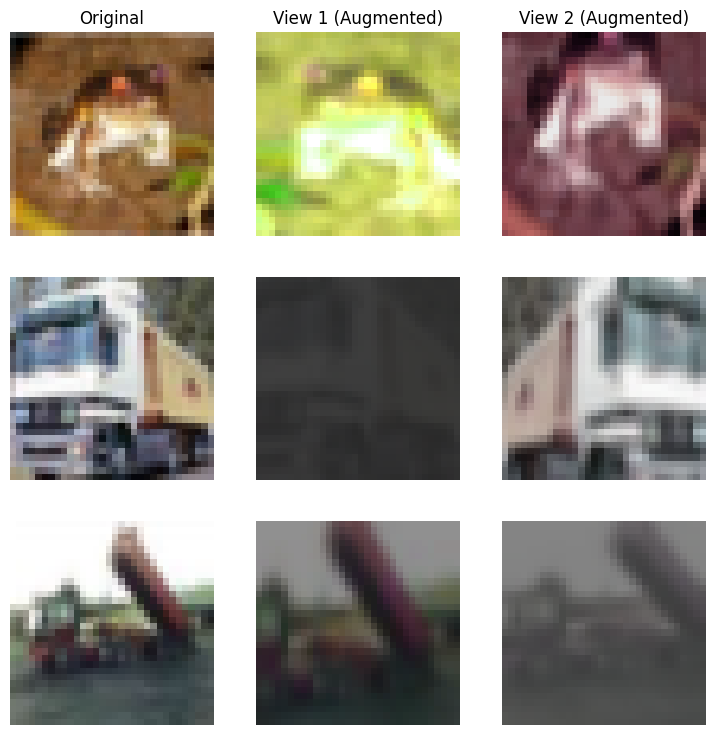

In [ ]:
# Load CIFAR-10
# Note: We discard labels for the training phase!
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True,
                                 transform=SimCLRTransform(size=32))

# Visualization Helper
def plot_augmentations(dataset):
    fig, axs = plt.subplots(3, 3, figsize=(9, 9))
    axs[0, 1].set_title("View 1 (Augmented)")
    axs[0, 2].set_title("View 2 (Augmented)")

    for i in range(3):
        # Get a raw image (no transform) for comparison
        raw_img = dataset.data[i]

        # Get augmented views
        img, _ = dataset[i] # This calls __call__ and returns (view1, view2), label
        view1, view2 = img

        # Original
        axs[i, 0].imshow(raw_img)
        axs[i, 0].axis('off')
        if i == 0: axs[i, 0].set_title("Original")

        # View 1
        axs[i, 1].imshow(view1.permute(1, 2, 0))
        axs[i, 1].axis('off')

        # View 2
        axs[i, 2].imshow(view2.permute(1, 2, 0))
        axs[i, 2].axis('off')
    plt.show()

print("Visualizing Augmentations (The model must learn these are the same object):")
plot_augmentations(train_dataset)

#Part 2: The Encoder & Projection Head
We use ResNet-18 as our backbone.
**Critical Detail:** We add a "Projection Head" (MLP) at the end. We calculate loss on the projection, but we throw it away later and keep the encoder features.

In [ ]:
class SimCLR(nn.Module):
    def __init__(self, base_model=models.resnet18, out_dim=128):
        super(SimCLR, self).__init__()

        # Load ResNet-18
        self.backbone = base_model(pretrained=False)

        # MODIFY RESNET FOR CIFAR-10
        # Standard ResNet is for 224x224 images. CIFAR is 32x32.
        # We replace the first 7x7 conv with a 3x3 conv to keep feature map size.
        self.backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.backbone.maxpool = nn.Identity() # Remove maxpool to prevent information loss too early

        # Get the dimension of the features before the final FC layer (usually 512 for ResNet18)
        dim_mlp = self.backbone.fc.in_features

        # Remove the original classification layer
        self.backbone.fc = nn.Identity()

        # Add the Projection Head (MLP)
        # Structure: Linear -> ReLU -> Linear
        self.projection_head = nn.Sequential(
            nn.Linear(dim_mlp, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim)
        )

    def forward(self, x):
        # h: Representation (features used for downstream tasks)
        h = self.backbone(x)

        # z: Projection (used for contrastive loss only)
        z = self.projection_head(h)
        return h, z

model = SimCLR().to(device)
print("Model created. Features dim: 512, Projection dim: 128")

Model created. Features dim: 512, Projection dim: 128


# ## Part 3: The Loss Function (NT-Xent)
This is the heart of SimCLR. It's where the main idea comes in to play. The main idea is to learn the features in such a way that two different views of the same sample will be represented as similar as possible while all other samples will be represented as distant as possible. By doing that for every sample in the batch, network learns a meaningful representation for the instances without the information about their label.

To implement this function, you need to:
1. Calculate Cosine Similarity between ALL images in the batch.
2. The "Positive Pairs" (augments of same image) should have high similarity.
3. Everything else (Negative Pairs) should have low similarity.



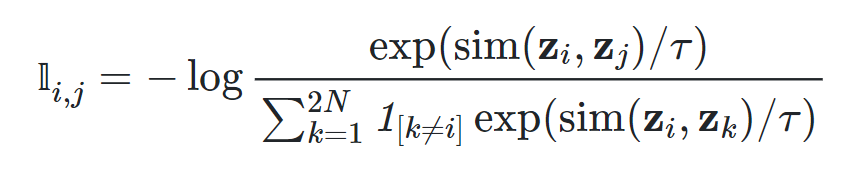

In [ ]:
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, z_i, z_j):
        """
        z_i, z_j: [Batch_Size, D] projections from view 1 and view 2
        """
        batch_size = z_i.shape[0]

        # 1. Concatenate both views: [2*B, D]
        z = torch.cat([z_i, z_j], dim=0)

        # 2. Normalize embeddings (Important for cosine similarity!)
        z = F.normalize(z, dim=1)

        # 3. Calculate Similarity Matrix (All vs All), divided by the temperature parameter
        # [2B, D] @ [D, 2B] -> [2B, 2B]
        similarity_matrix = torch.matmul(z, z.T) / self.temperature

        # 4. Create Labels
        # For the i-th image, its positive pair is at index (i + batch_size)
        # We want the diagonal offset by batch_size to be the target.
        # So we should create a list such as [N, N+1, ..., 2N-1, 0, 1, ..., N-1]

        labels = torch.cat([
            torch.arange(batch_size) + batch_size, # i matches with i+B
            torch.arange(batch_size)               # i+B matches with i
        ]).to(z.device)

        # 5. Mask out self-similarity (similarity of image with itself is not useful)
        mask = torch.eye(2 * batch_size, dtype=torch.bool).to(z.device)
        # We fill diagonal with a very small number so it doesn't affect Softmax
        similarity_matrix.masked_fill_(mask, -9e15)

        # 6. Compute Loss
        loss = self.criterion(similarity_matrix, labels)

        return loss

# Instantiate our criterion
criterion = NTXentLoss(temperature=0.5)

# Part 4: Training & The "Hypersphere"
We will train for a few epochs.
We also define a visualization function to see how the points move on the "Hypersphere".
Ideally, similar classes should cluster together on the sphere's surface.

Starting training...


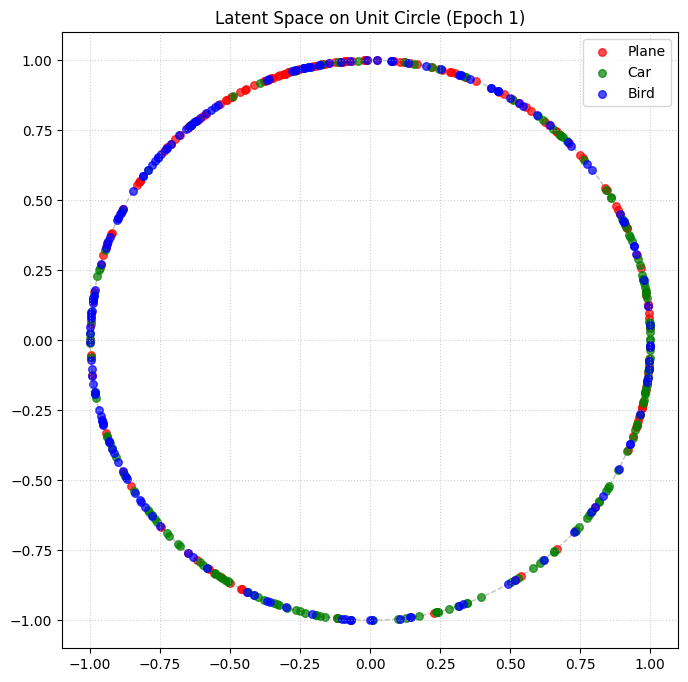

Epoch 1/10 | Loss: 4.6023
Epoch 2/10 | Loss: 4.2427
Epoch 3/10 | Loss: 4.1303
Epoch 4/10 | Loss: 4.0557


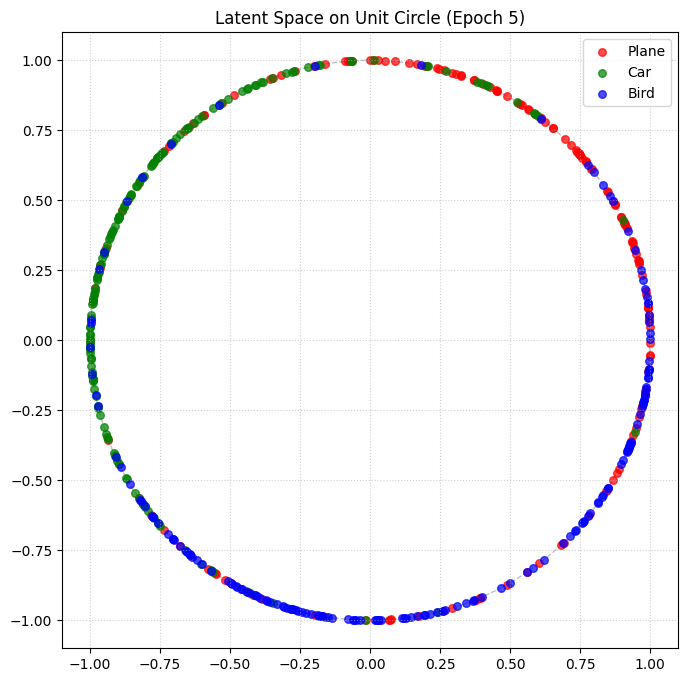

Epoch 5/10 | Loss: 4.0041
Epoch 6/10 | Loss: 3.9677
Epoch 7/10 | Loss: 3.9418
Epoch 8/10 | Loss: 3.9236
Epoch 9/10 | Loss: 3.9068


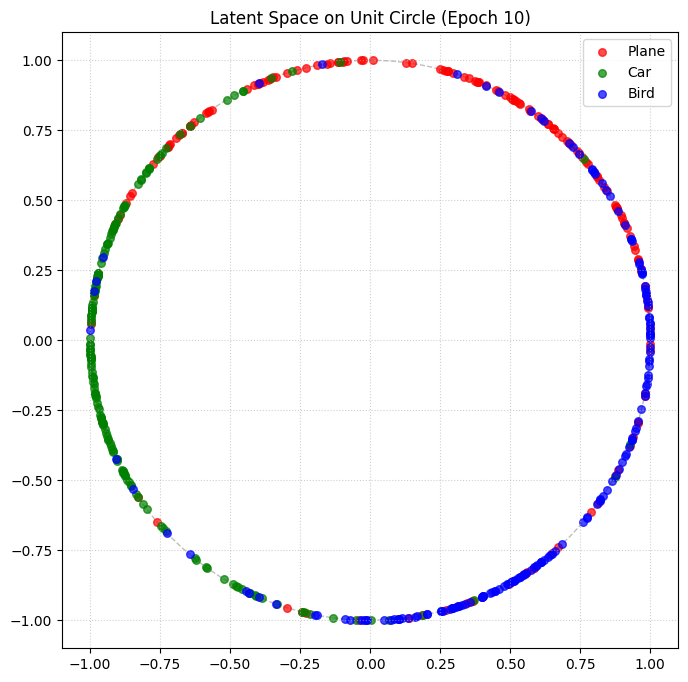

Epoch 10/10 | Loss: 3.8952


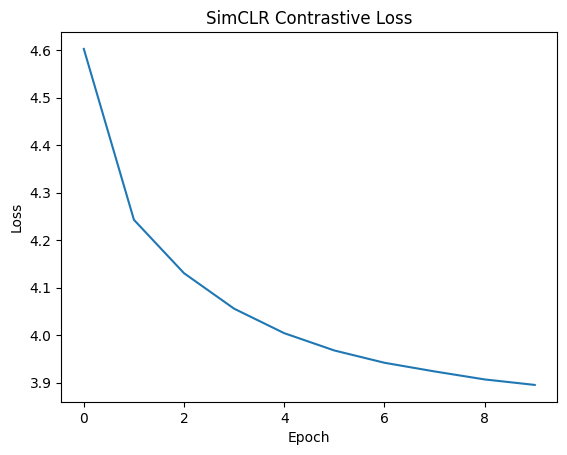

In [ ]:
# Config
BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-3

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=2)
optimizer = optim.Adam(model.parameters(), lr=LR)

# Helper to visualize latent space (Hypersphere Projection)
def visualize_hypersphere(model, epoch):
    model.eval()
    features, labels = [], []

    test_dataset = datasets.CIFAR10(root='./data', train=False, transform=transforms.ToTensor())
    indices = [i for i, t in enumerate(test_dataset.targets) if t in [0, 1, 2]] # Plane, Car, Bird
    subset = torch.utils.data.Subset(test_dataset, indices[:500])
    vloader = DataLoader(subset, batch_size=100)

    with torch.no_grad():
        for img, lbl in vloader:
            img = img.to(device)
            h, _ = model(img)
            h = F.normalize(h, dim=1)
            features.append(h.cpu().numpy())
            labels.append(lbl.numpy())

    features = np.concatenate(features)
    labels = np.concatenate(labels)

    # PCA to 2D for plotting (Projection to Unit Circle)
    pca = PCA(n_components=2)
    projected = pca.fit_transform(features)

    # Normalize again to force onto unit circle for visualization
    # This shows "cosine similarity" as "angular distance"
    projected = projected / np.linalg.norm(projected, axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(8, 8))

    # Draw Unit Circle for context
    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.5)
    ax.add_artist(circle)

    colors = ['r', 'g', 'b']
    names = ['Plane', 'Car', 'Bird']

    for i in range(3):
        idx = labels == i
        ax.scatter(projected[idx, 0], projected[idx, 1],
                   c=colors[i], label=names[i], alpha=0.7, s=30)

    ax.set_title(f"Latent Space on Unit Circle (Epoch {epoch})")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
    model.train()

# Training
loss_history = []
print("Starting training...")
for epoch in range(EPOCHS):
    # Visualize every 5 epochs and at the start
    if epoch == 0 or (epoch + 1) % 5 == 0:
        visualize_hypersphere(model, epoch+1)

    total_loss = 0
    for (view1, view2), _ in train_loader: # Ignore labels!
        view1, view2 = view1.to(device), view2.to(device)

        optimizer.zero_grad()
        _, z1 = model(view1)
        _, z2 = model(view2)

        loss = criterion(z1, z2)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f}")

plt.plot(loss_history)
plt.title("SimCLR Contrastive Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Part 5: Linear Evaluation (The "Probe")
Did we learn anything?
We will freeze the encoder and train a simple Linear Classifier on top.
If the features are good, this simple classifier should perform well (much better than chance, which is 10%).

In [ ]:
from sklearn.linear_model import LogisticRegression

def get_features(model, loader):
    model.eval()
    features = []
    labels = []
    with torch.no_grad():
        for img, lbl in loader:
            img = img.to(device)
            h, _ = model(img)
            features.append(h.cpu())
            labels.append(lbl)
    return torch.cat(features), torch.cat(labels)

def evaluate_model(model, train_loader, test_loader, title):
    print(f"\n--- Evaluating {title} ---")
    print("Extracting features...")
    X_train, y_train = get_features(model, train_loader)
    X_test, y_test = get_features(model, test_loader)

    print(f"Features shape: {X_train.shape}")
    print("Training Linear Classifier (Logistic Regression)...")

    # Train Logistic Regression
    clf = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial')
    clf.fit(X_train.numpy(), y_train.numpy())

    score = clf.score(X_test.numpy(), y_test.numpy())
    print(f"{title} Accuracy: {score*100:.2f}%")
    return score

# Prepare loaders with standard transform (no jitter for eval)
eval_train_dataset = datasets.CIFAR10(root='./data', train=True, transform=transforms.ToTensor())
eval_test_dataset = datasets.CIFAR10(root='./data', train=False, transform=transforms.ToTensor())

eval_train_loader = DataLoader(eval_train_dataset, batch_size=512, shuffle=False)
eval_test_loader = DataLoader(eval_test_dataset, batch_size=512, shuffle=False)

# 1. Baseline: Randomly Initialized Network
# We create a fresh SimCLR model (random weights) to see how well random features perform. Let's use the SimCLR module
# also for the randomly initialized model.
random_model = SimCLR().to(device)
random_acc = evaluate_model(random_model, eval_train_loader, eval_test_loader, "Random Baseline")

# 2. SimCLR: Pretrained Network
simclr_acc = evaluate_model(model, eval_train_loader, eval_test_loader, "Contrastive Pretrained")

print(f"\nImprovement due to Contrastive Learning: +{(simclr_acc - random_acc)*100:.2f}%")


--- Evaluating Random Baseline ---
Extracting features...
Features shape: torch.Size([50000, 512])
Training Linear Classifier (Logistic Regression)...
Random Baseline Accuracy: 46.10%

--- Evaluating Contrastive Pretrained ---
Extracting features...
Features shape: torch.Size([50000, 512])
Training Linear Classifier (Logistic Regression)...
Contrastive Pretrained Accuracy: 70.92%

Improvement due to Contrastive Learning: +24.82%
